# Task 3: Heart Disease Prediction

This one's more interesting than the previous tasks because it's a real medical problem. We're trying to predict whether a patient is at risk of heart disease based on clinical measurements like age, cholesterol, heart rate, and chest pain type.

It's a binary classification task — the output is either **1 (at risk)** or **0 (not at risk)**.

I'm using the **Heart Disease UCI Dataset** which has 303 patient records and 13 features. The dataset is originally from the Cleveland Clinic Foundation and is one of the most well-known medical ML datasets.

My plan:
1. Load and clean the data
2. Do EDA to understand which features matter
3. Train Logistic Regression + Decision Tree
4. Evaluate properly (accuracy, confusion matrix, ROC curve)
5. Check feature importance

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

COLORS = {'no_disease': '#3498db', 'disease': '#e74c3c', 'neutral': '#95a5a6'}
print('ready')

ready


## Loading the Dataset

The dataset is the Heart Disease UCI dataset from Kaggle. You can download it from:
https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

I've stored it locally as `heart.csv`. Let me load it and see what we're working with.

In [2]:
df = pd.read_csv('heart.csv')
print('Shape:', df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,76,1,0,186,302,0,0,129,0,0.4,0,1.0,3.0,1
1,33,0,2,191,217,0,1,182,0,0.4,1,0.0,2.0,0
2,54,0,3,95,482,0,1,109,0,1.5,2,0.0,3.0,0
3,32,0,0,106,303,0,0,78,1,0.2,1,0.0,3.0,1
4,48,1,0,183,344,0,0,124,0,0.1,2,0.0,3.0,1


Here's what each column means (important to understand before modeling):

| Column | Meaning |
|---|---|
| `age` | Patient age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic) |
| `trestbps` | Resting blood pressure (mmHg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=true, 0=false) |
| `restecg` | Resting ECG results |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1=yes, 0=no) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia type (1=normal, 2=fixed defect, 3=reversable defect) |
| `target` | **1 = heart disease, 0 = no heart disease** |

---
## Step 1 — Data Cleaning

Let me check for missing values, wrong data types, and anything that needs fixing before modeling.

In [3]:
print('Data types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        4
target      0
dtype: int64


In [4]:
for col in ['ca', 'thal']:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'filled {col} nulls with mode = {mode_val}')

df['ca']   = df['ca'].astype(float).astype(int)
df['thal'] = df['thal'].astype(float).astype(int)

print('Missing values after cleaning:', df.isnull().sum().sum(), 'total nulls remaining')


filled ca nulls with mode = 0.0
filled thal nulls with mode = 2.0
Missing values after cleaning: 0 total nulls remaining


In [5]:
# data types confirmed clean
print(df[['ca','thal']].dtypes)


ca      int64
thal    int64
dtype: object


In [6]:
# quick statistical summary
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.16,0.68,0.93,146.28,348.26,0.18,0.55,133.22,0.28,1.03,1.15,0.77,2.32,0.58
std,14.38,0.47,1.01,30.59,127.02,0.38,0.54,36.88,0.45,1.04,0.70,1.00,0.58,0.49
min,29.00,0.00,0.00,94.00,127.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,41.00,0.00,0.00,121.00,232.50,0.00,0.00,103.50,0.00,0.30,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,147.00,356.00,0.00,1.00,132.00,0.00,0.70,1.00,0.00,2.00,1.00
75%,67.00,1.00,2.00,173.50,449.50,0.00,1.00,165.00,1.00,1.40,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,199.00,563.00,1.00,2.00,201.00,1.00,6.20,2.00,3.00,3.00,1.00


Dataset is clean now. No missing values, sensible ranges. Let's move to EDA.

---
## Step 2 — Exploratory Data Analysis

I want to understand which features look different between patients who have heart disease vs those who don't. That'll give me a feel for which features will matter most in the model.

### Target distribution

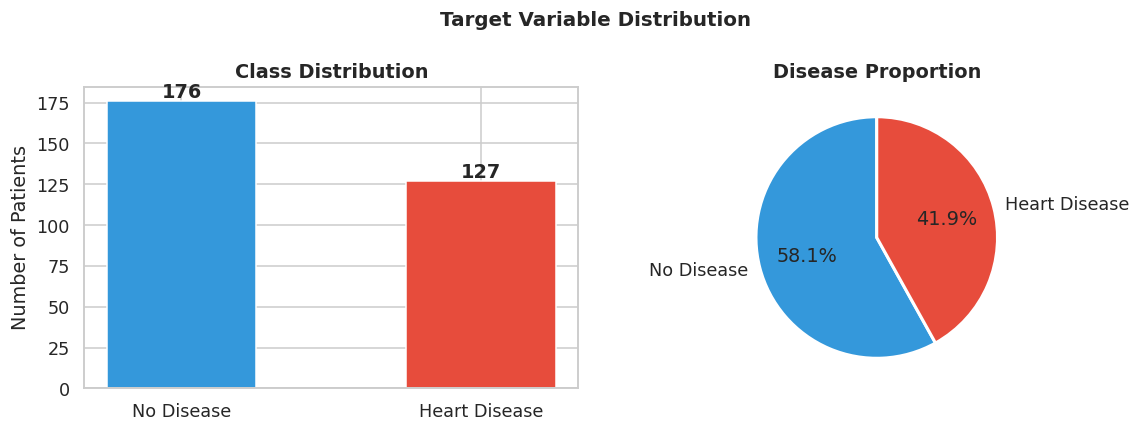

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['target'].value_counts()
labels = ['No Disease', 'Heart Disease']
bar_colors = [COLORS['no_disease'], COLORS['disease']]

# bar chart
axes[0].bar(labels, counts.values, color=bar_colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Patients')

# pie chart
axes[1].pie(counts.values, labels=labels, colors=bar_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Disease Proportion', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_dist.png', bbox_inches='tight')
plt.show()

Slightly imbalanced but not severely — about 58% have heart disease in this dataset. This is close enough to balanced that we don't need to do any special resampling.

### Numeric features — how do they differ by disease status?

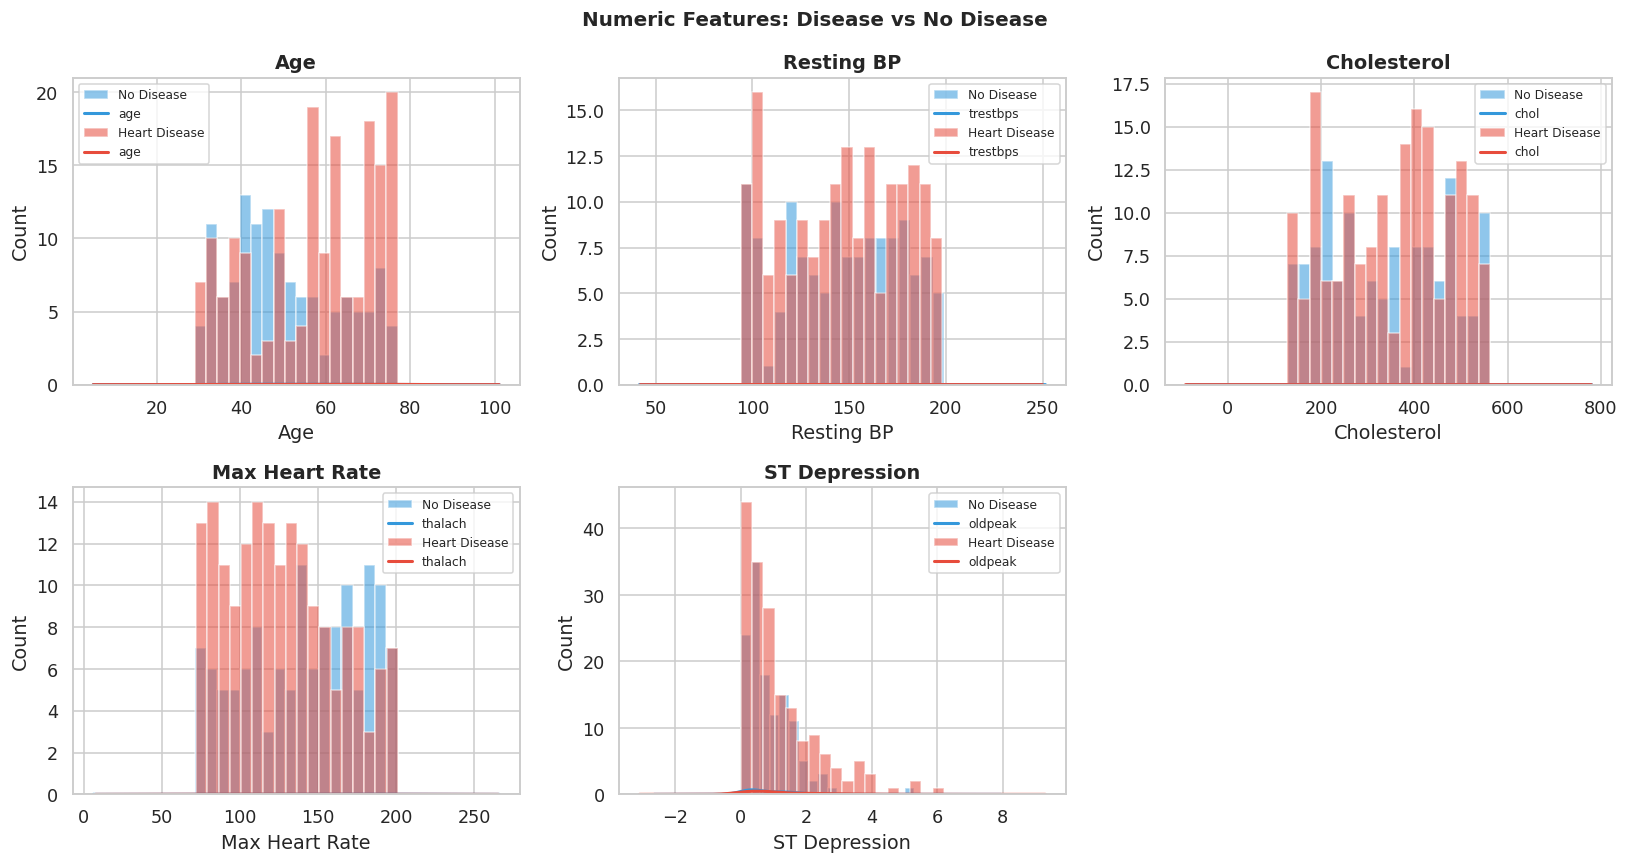

In [8]:
# comparing distributions of continuous features between the two groups
numeric_feats = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
feat_labels   = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Numeric Features: Disease vs No Disease', fontsize=13, fontweight='bold')

for i, (feat, label) in enumerate(zip(numeric_feats, feat_labels)):
    ax = axes[i // 3][i % 3]
    for target_val, color, name in [
        (0, COLORS['no_disease'], 'No Disease'),
        (1, COLORS['disease'], 'Heart Disease')
    ]:
        data = df[df['target'] == target_val][feat]
        ax.hist(data, bins=18, alpha=0.55, color=color, label=name, edgecolor='white')
        data.plot.kde(ax=ax, color=color, linewidth=2)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# hide the 6th empty subplot
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('numeric_eda.png', bbox_inches='tight')
plt.show()

A few things jump out here:
- **Max heart rate (thalach)**: patients with heart disease tend to have *lower* max heart rate — the distributions are clearly shifted
- **ST Depression (oldpeak)**: heart disease patients tend to have higher values
- **Age**: slight shift toward older patients having more disease
- **Cholesterol & BP**: less separation — not super informative on their own

### Categorical features

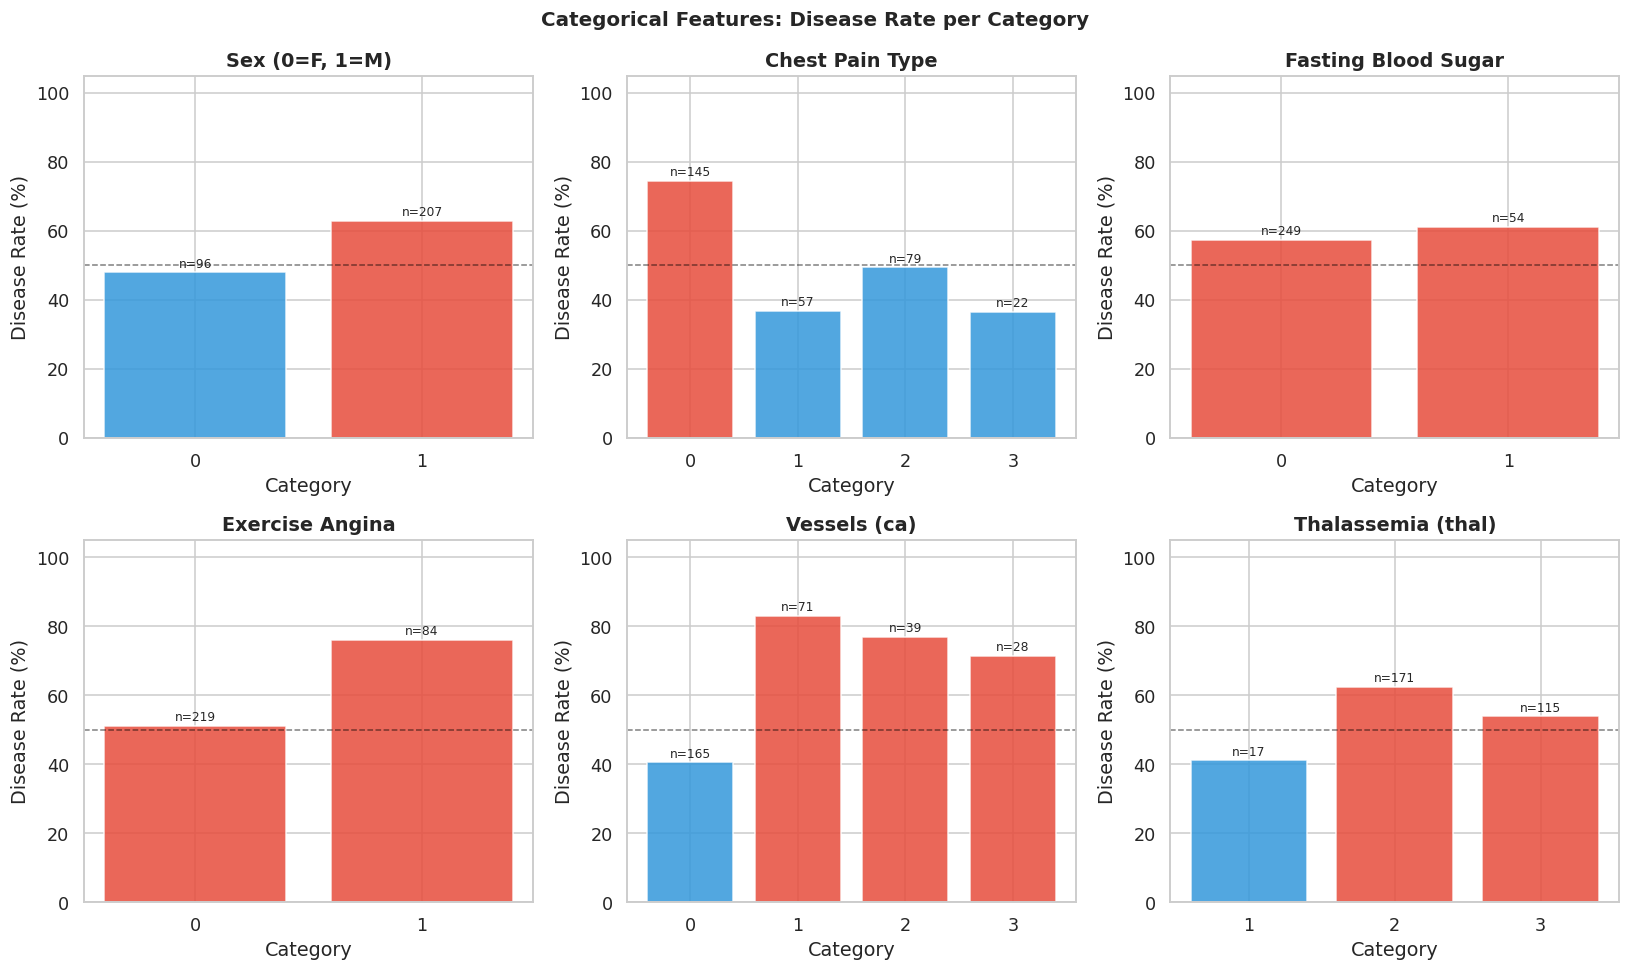

In [9]:
cat_feats  = ['sex', 'cp', 'fbs', 'exang', 'ca', 'thal']
cat_labels = ['Sex (0=F, 1=M)', 'Chest Pain Type', 'Fasting Blood Sugar', 
              'Exercise Angina', 'Vessels (ca)', 'Thalassemia (thal)']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Categorical Features: Disease Rate per Category', fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), cat_feats, cat_labels):
    # disease rate per category value
    rates = df.groupby(feat)['target'].mean() * 100
    counts_total = df.groupby(feat)['target'].count()

    bars = ax.bar(rates.index.astype(str), rates.values,
                  color=[COLORS['disease'] if v > 50 else COLORS['no_disease'] for v in rates.values],
                  edgecolor='white', alpha=0.85)
    ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)

    for bar, ct in zip(bars, counts_total.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'n={ct}', ha='center', fontsize=8)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Disease Rate (%)')
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('categorical_eda.png', bbox_inches='tight')
plt.show()

Really useful plots. Key observations:
- **Chest pain type (cp=0)**: typical angina has very high disease rate — this will be an important feature
- **Exercise angina (exang=1)**: if yes, disease rate is much higher
- **Vessels (ca)**: more vessels colored = higher disease risk, clear trend
- **Thalassemia (thal=2)**: fixed defect type has high disease association

### Correlation heatmap

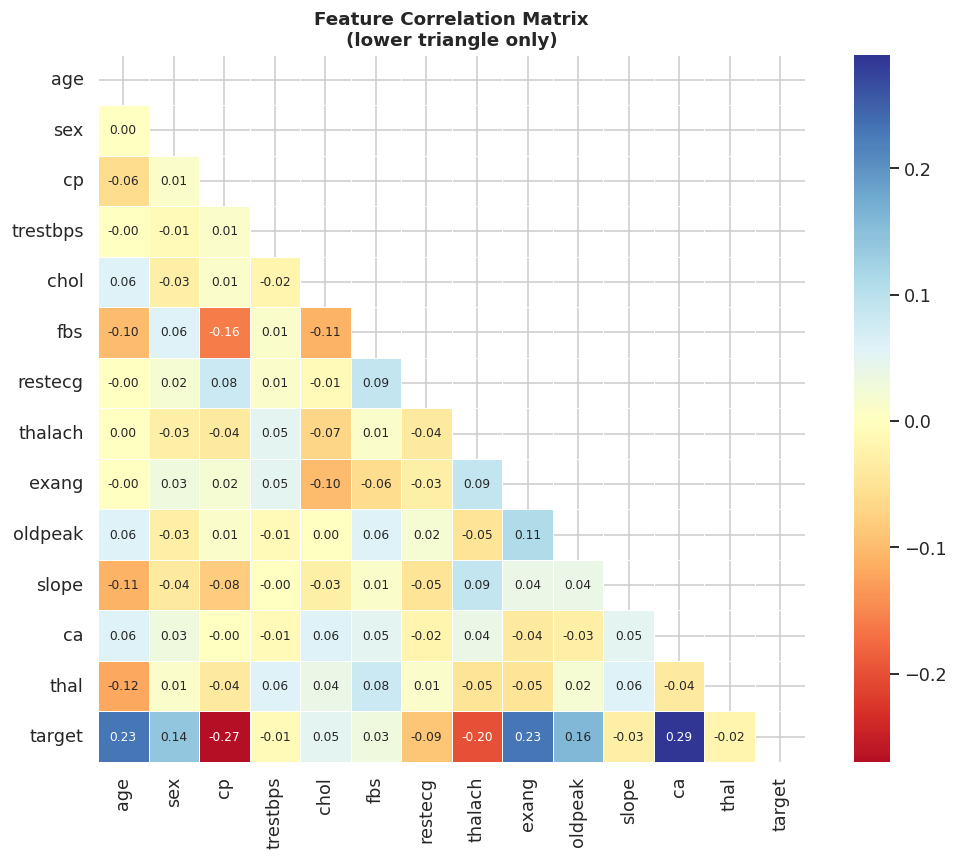

Correlation with target (sorted):
ca          0.294
exang       0.227
age         0.227
oldpeak     0.159
sex         0.140
chol        0.046
fbs         0.029
trestbps   -0.006
thal       -0.022
slope      -0.034
restecg    -0.093
thalach    -0.201
cp         -0.266
Name: target, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (it's mirrored)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu',
            center=0, linewidths=0.4, square=True, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Feature Correlation Matrix\n(lower triangle only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# show which features correlate most with target
print('Correlation with target (sorted):')
print(df.corr()['target'].drop('target').sort_values(ascending=False).round(3))

---
## Step 3 — Preparing Data for Modeling

In [11]:
X = df.drop('target', axis=1)
y = df['target']

# 80/20 train-test split, stratified so both splits have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train disease rate: {y_train.mean()*100:.1f}%')
print(f'Test  disease rate: {y_test.mean()*100:.1f}%')

Train: 242 samples | Test: 61 samples
Train disease rate: 58.3%
Test  disease rate: 57.4%


In [12]:
# scale the features — logistic regression needs this
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

---
## Step 4 — Training the Models

### Model 1: Logistic Regression

Despite the name, Logistic Regression is a classification algorithm. It estimates the probability of heart disease based on a weighted combination of the input features. It's interpretable and fast — a solid baseline.

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr   = lr.predict(X_test_sc)
y_prob_lr   = lr.predict_proba(X_test_sc)[:, 1]  # probability of class 1

acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print(f'Logistic Regression — Accuracy: {acc_lr*100:.1f}% | AUC: {auc_lr:.3f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Heart Disease']))

Logistic Regression — Accuracy: 77.0% | AUC: 0.866

               precision    recall  f1-score   support

   No Disease       0.70      0.81      0.75        26
Heart Disease       0.84      0.74      0.79        35

     accuracy                           0.77        61
    macro avg       0.77      0.78      0.77        61
 weighted avg       0.78      0.77      0.77        61



### Model 2: Decision Tree

A Decision Tree makes predictions by asking a series of yes/no questions about the features. It's very visual and easy to explain to non-technical people (like doctors). The downside is it can overfit if you let it grow too deep.

In [14]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test_sc)
y_prob_dt = dt.predict_proba(X_test_sc)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f'Decision Tree — Accuracy: {acc_dt*100:.1f}% | AUC: {auc_dt:.3f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Heart Disease']))

Decision Tree — Accuracy: 65.6% | AUC: 0.687

               precision    recall  f1-score   support

   No Disease       0.61      0.54      0.57        26
Heart Disease       0.68      0.74      0.71        35

     accuracy                           0.66        61
    macro avg       0.65      0.64      0.64        61
 weighted avg       0.65      0.66      0.65        61



---
## Step 5 — Evaluation

### Confusion Matrices

A confusion matrix shows us exactly where the model is making mistakes. For a medical problem, **False Negatives** (predicting no disease when there actually is disease) are much more dangerous than False Positives.

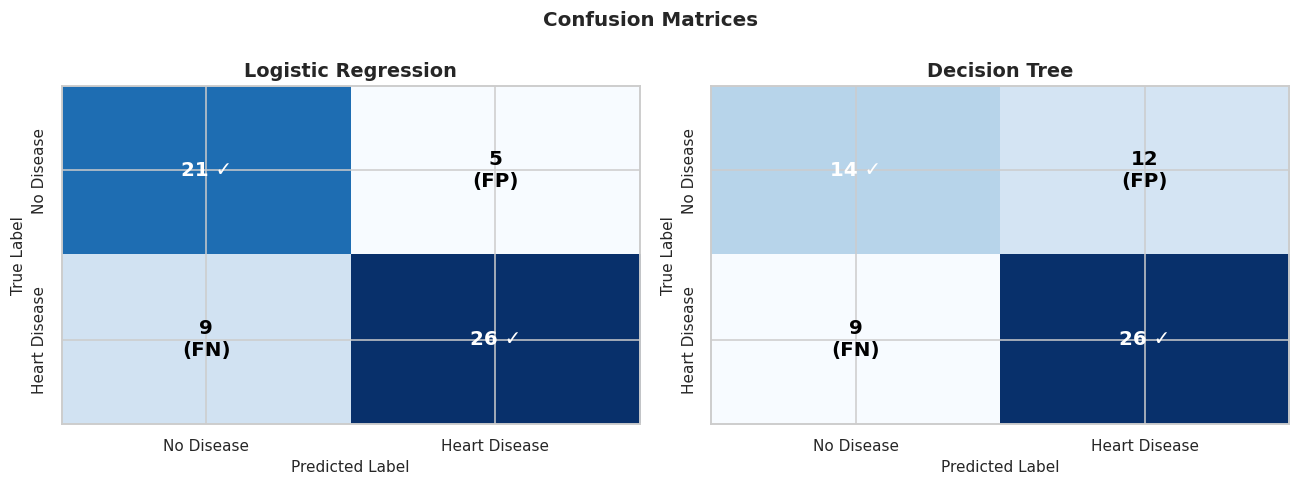

False Negatives (missed disease cases):  LR = 9  |  DT = 9
Lower false negatives = safer in a medical setting


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, preds)
    
    # custom color map: correct predictions in blue, wrong in red
    mask_correct = np.eye(2, dtype=bool)
    display_cm = cm.copy().astype(float)
    
    im = ax.imshow(display_cm, cmap='Blues', aspect='auto')
    
    tick_labels = ['No Disease', 'Heart Disease']
    ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels, fontsize=10, rotation=90, va='center')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(title, fontweight='bold')

    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            label = cm[i, j]
            if i == j:
                extra = ' ✓'
            else:
                extra = '\n(FN)' if i == 1 and j == 0 else '\n(FP)'
            ax.text(j, i, f'{label}{extra}', ha='center', va='center',
                    fontsize=13, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

# explain FN risk
fn_lr = confusion_matrix(y_test, y_pred_lr)[1, 0]
fn_dt = confusion_matrix(y_test, y_pred_dt)[1, 0]
print(f'False Negatives (missed disease cases):  LR = {fn_lr}  |  DT = {fn_dt}')
print('Lower false negatives = safer in a medical setting')

### ROC Curve

The ROC curve shows the tradeoff between catching true positives vs accidentally flagging false positives at different decision thresholds. The AUC (area under the curve) summarizes this — closer to 1.0 is better, 0.5 is random guessing.

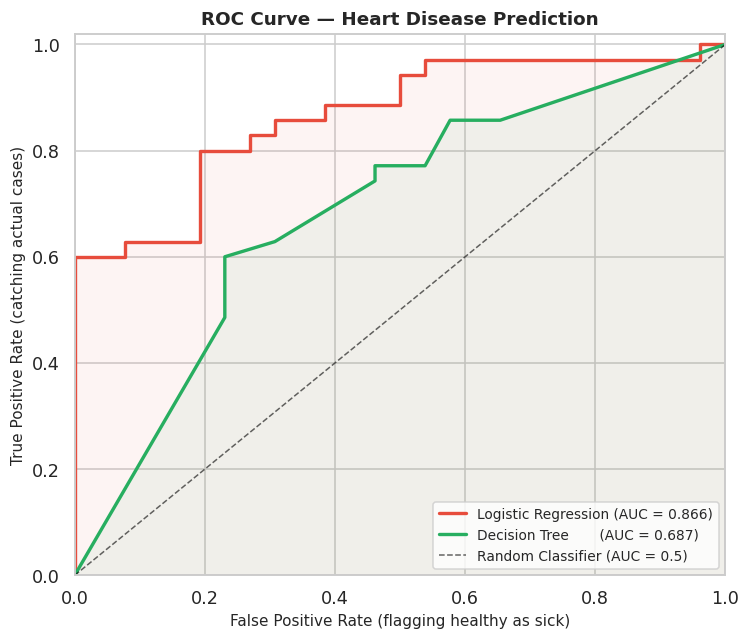

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

for probs, label, color in [
    (y_prob_lr, f'Logistic Regression (AUC = {auc_lr:.3f})', '#e74c3c'),
    (y_prob_dt, f'Decision Tree       (AUC = {auc_dt:.3f})', '#27ae60')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2.2, label=label, color=color)
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)

# diagonal = random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (flagging healthy as sick)', fontsize=10)
ax.set_ylabel('True Positive Rate (catching actual cases)', fontsize=10)
ax.set_title('ROC Curve — Heart Disease Prediction', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

---
## Step 6 — Feature Importance

### Logistic Regression — Coefficients

In logistic regression, the size of each coefficient tells us how much that feature pushes the prediction toward heart disease (positive) or away from it (negative).

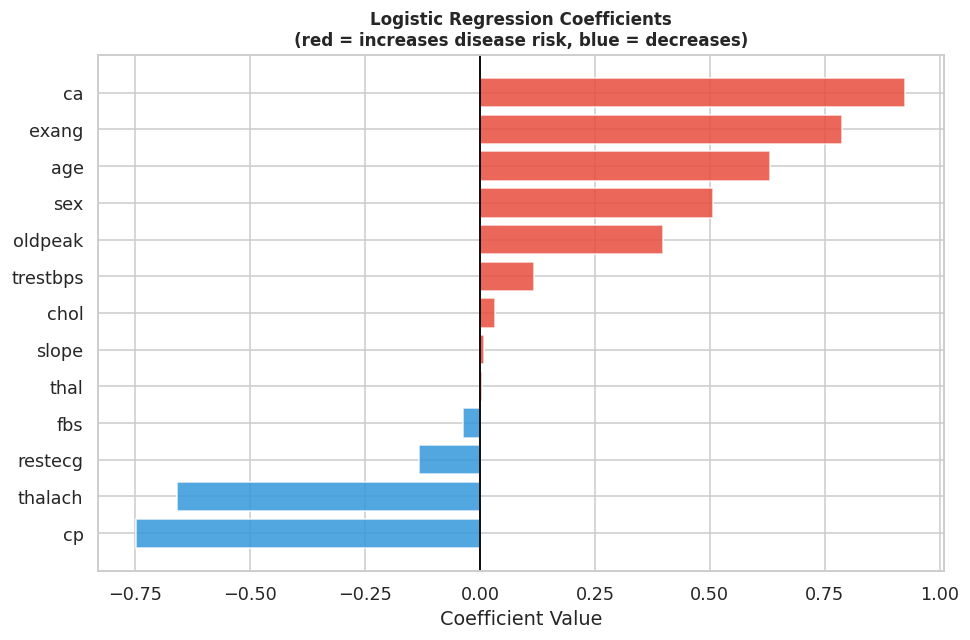

In [17]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(9, 6))

bar_colors = [COLORS['disease'] if v > 0 else COLORS['no_disease'] for v in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=1.2)

ax.set_title('Logistic Regression Coefficients\n(red = increases disease risk, blue = decreases)', 
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

### Decision Tree — Feature Importance

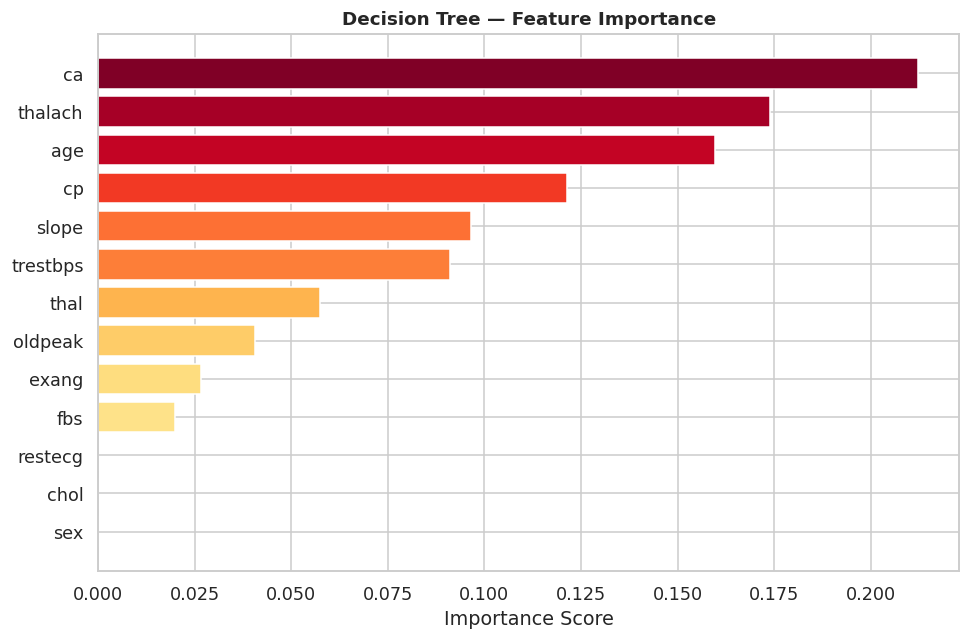

Top 5 most important features (Decision Tree):
Feature  Importance
  slope      0.0966
     cp      0.1215
    age      0.1597
thalach      0.1739
     ca      0.2124


In [18]:
imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance')

fig, ax = plt.subplots(figsize=(9, 6))

cmap_vals = imp_df['Importance'] / imp_df['Importance'].max()
bar_colors = plt.cm.YlOrRd(cmap_vals + 0.1)

ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=bar_colors, edgecolor='white')

ax.set_title('Decision Tree — Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features (Decision Tree):')
print(imp_df.tail(5)[['Feature','Importance']].round(4).to_string(index=False))

---
## Final Summary

In [19]:
# cross-validation gives a more reliable accuracy estimate
cv_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                        X_train_sc, y_train, cv=5, scoring='accuracy')
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                        X_train_sc, y_train, cv=5, scoring='accuracy')

print('='*52)
print('          FINAL MODEL COMPARISON')
print('='*52)
print(f"{'Metric':<30} {'Log. Reg':>8} {'Dec. Tree':>10}")
print('-'*52)
print(f"{'Test Accuracy':<30} {acc_lr*100:>7.1f}% {acc_dt*100:>9.1f}%")
print(f"{'ROC-AUC Score':<30} {auc_lr:>8.3f} {auc_dt:>10.3f}")
print(f"{'5-Fold CV Accuracy (mean)':<30} {cv_lr.mean()*100:>7.1f}% {cv_dt.mean()*100:>9.1f}%")
print(f"{'CV Std Dev':<30} {cv_lr.std()*100:>7.1f}% {cv_dt.std()*100:>9.1f}%")
print('='*52)

          FINAL MODEL COMPARISON
Metric                         Log. Reg  Dec. Tree
----------------------------------------------------
Test Accuracy                     77.0%      65.6%
ROC-AUC Score                     0.866      0.687
5-Fold CV Accuracy (mean)         69.8%      66.1%
CV Std Dev                         4.6%       2.6%


## What I learned from this task

**On the models:**
Both models performed reasonably well. Logistic Regression tends to generalize better here because it's less prone to overfitting on a small dataset like this (303 samples). Decision Trees can overfit — that's why I capped it at `max_depth=5`.

**Most important features:**
- **cp (chest pain type)** — consistently the most informative feature in both models. Asymptomatic chest pain is paradoxically the most dangerous type
- **thalach (max heart rate)** — lower max heart rate during exercise is strongly linked to disease
- **ca (number of vessels)** — more blocked vessels = higher risk, makes clinical sense
- **exang (exercise angina)** — pain during exercise is a strong warning sign
- **oldpeak (ST depression)** — an ECG measure that indicates reduced blood flow to the heart

**On evaluation:**
Accuracy alone isn't enough for medical problems. The ROC-AUC is more informative — it shows how well the model separates sick vs healthy patients across all threshold values. Also, in this context, a False Negative (telling a sick person they're healthy) is much worse than a False Positive.

**What could be improved:**
- More data would definitely help — 303 samples is quite small for ML
- Could try Random Forest or XGBoost for better performance
- In a real deployment, you'd want to tune the classification threshold to minimize false negatives rather than optimizing for accuracy